In [3]:
%load_ext autoreload
%autoreload 2
import torch
import utils
from dataset import get_data
from modules import TGEmbedder, TGRecovery, TGSupervisor, TGGenerator, TGDiscriminator, tg_generate

train_loader, val_w, test_w, stats = get_data("~/Desktop/LOBSTER")
print(f"Validation windows: {tuple(val_w.shape)}   expect (697, 24, 40)")

Validation windows: (697, 24, 40)   expect (697, 24, 40)


In [5]:
import torch, utils
from modules import TGEmbedder, TGRecovery, TGSupervisor, TGGenerator, TGDiscriminator, tg_generate

ckpt = torch.load("checkpoints/timegan_s0.pt", weights_only=False, map_location="cpu")
nets = {"E": TGEmbedder(), "R": TGRecovery(), "S": TGSupervisor(), "G": TGGenerator(), "D": TGDiscriminator()}
for k, n in nets.items():
    n.load_state_dict(ckpt[k]); n.eval()

torch.manual_seed(1234)                                       # same noise as train.py's evaluation
fake = tg_generate(nets["G"], nets["S"], nets["R"], len(val_w))
stats = ckpt["stats"]                                         # training stats saved with the model

x = utils.unnormalise(fake, stats)
ix = utils.feature_index(stats)
print(f"Any invariant broken: {utils.invariant_rates(x, ix)['Any invariant broken']:.1f}%   expect ~51.9% (matches the JSON)")
for side in ["ask_gap", "bid_gap"]:
    rates = [(x[..., i] <= 0).float().mean().item() * 100 for i in ix[side]]
    print(side, " ".join(f"L{n+1}-{n+2}:{r:4.1f}%" for n, r in enumerate(rates)), "  (% of books where this gap is <= 0)")

Any invariant broken: 50.5%   expect ~51.9% (matches the JSON)
ask_gap L1-2: 7.7% L2-3: 8.3% L3-4: 2.9% L4-5: 4.4% L5-6: 4.9% L6-7: 5.1% L7-8: 5.9% L8-9: 4.7% L9-10: 4.5%   (% of books where this gap is <= 0)
bid_gap L1-2: 4.9% L2-3: 6.1% L3-4: 2.3% L4-5: 6.2% L5-6: 4.9% L6-7: 2.5% L7-8: 2.7% L8-9: 3.7% L9-10: 3.8%   (% of books where this gap is <= 0)


## Price paths

**rnngan, seed 0**

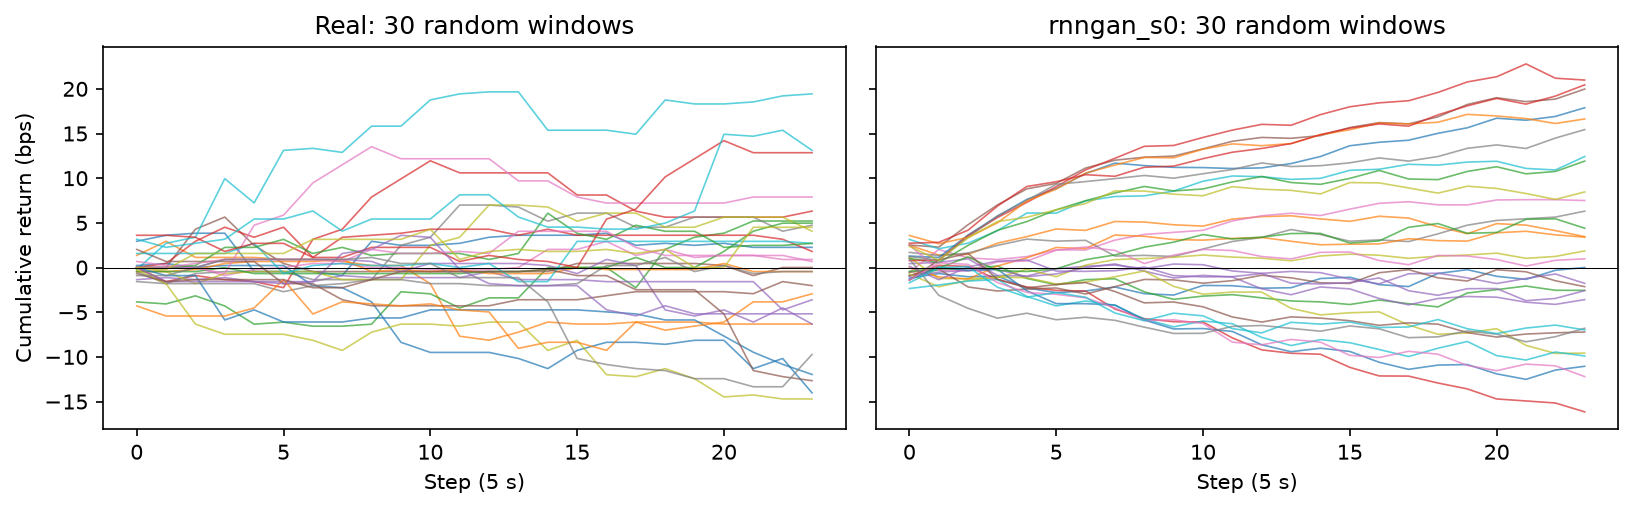

**rnngan, seed 1**

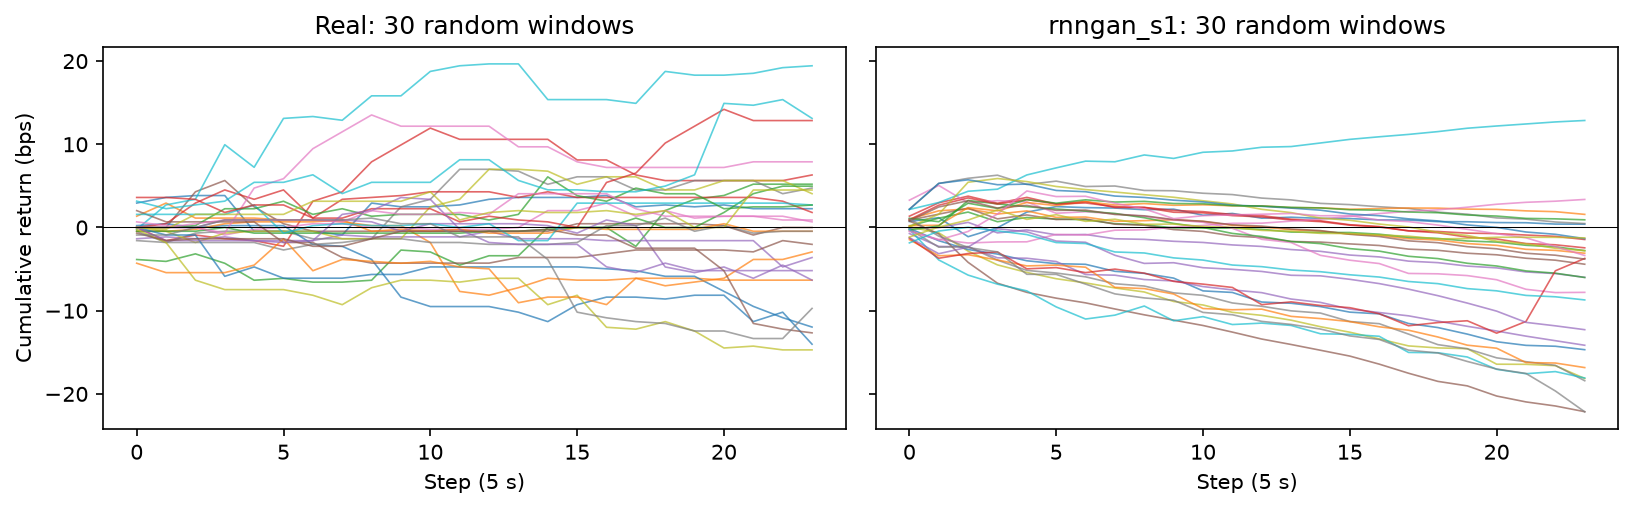

**rnngan, seed 2**

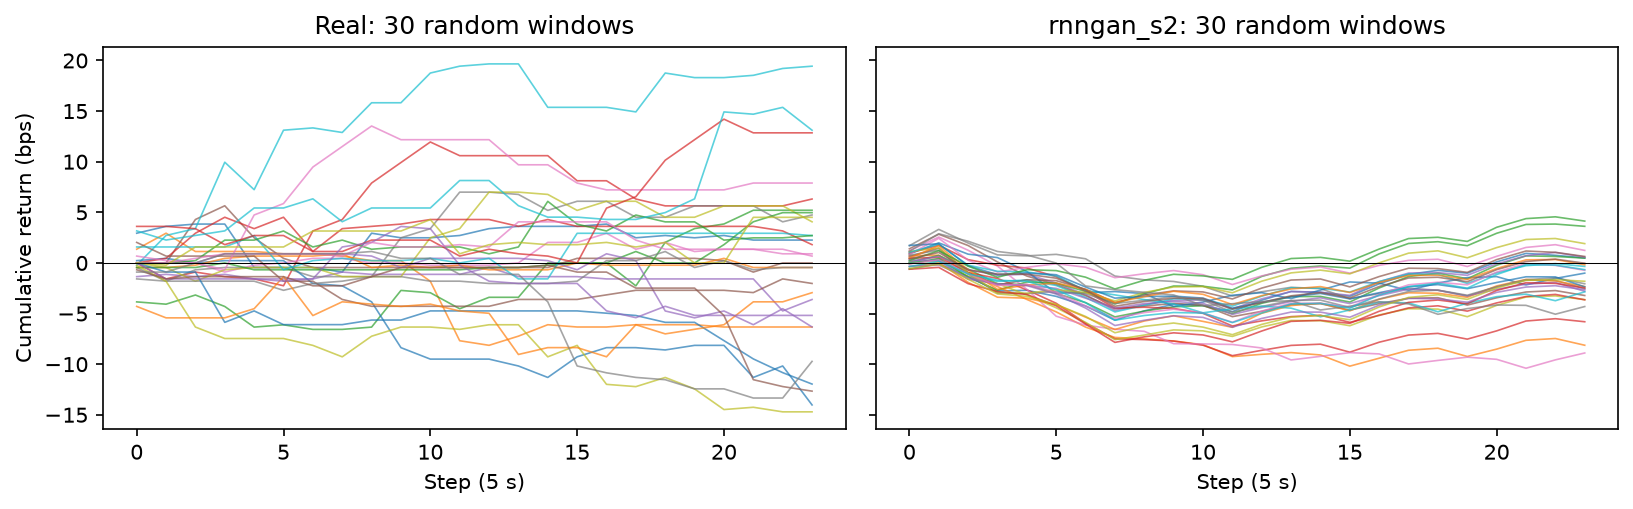

**timegan, seed 0**

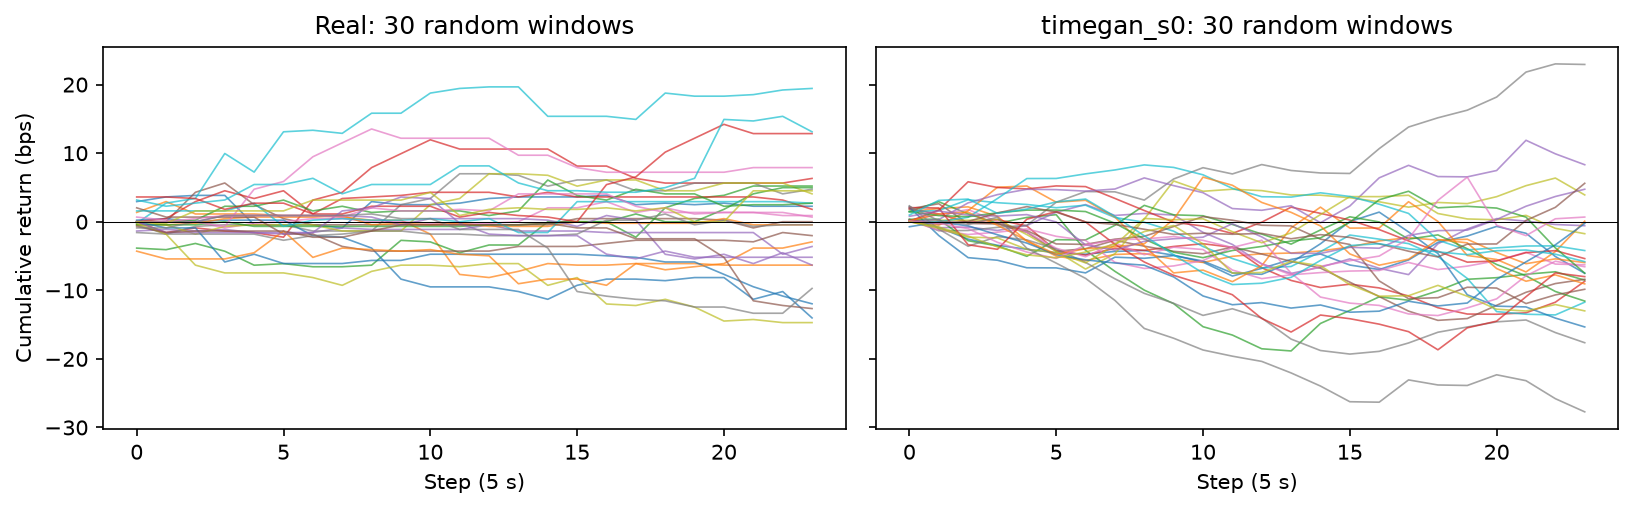

**timegan, seed 1**

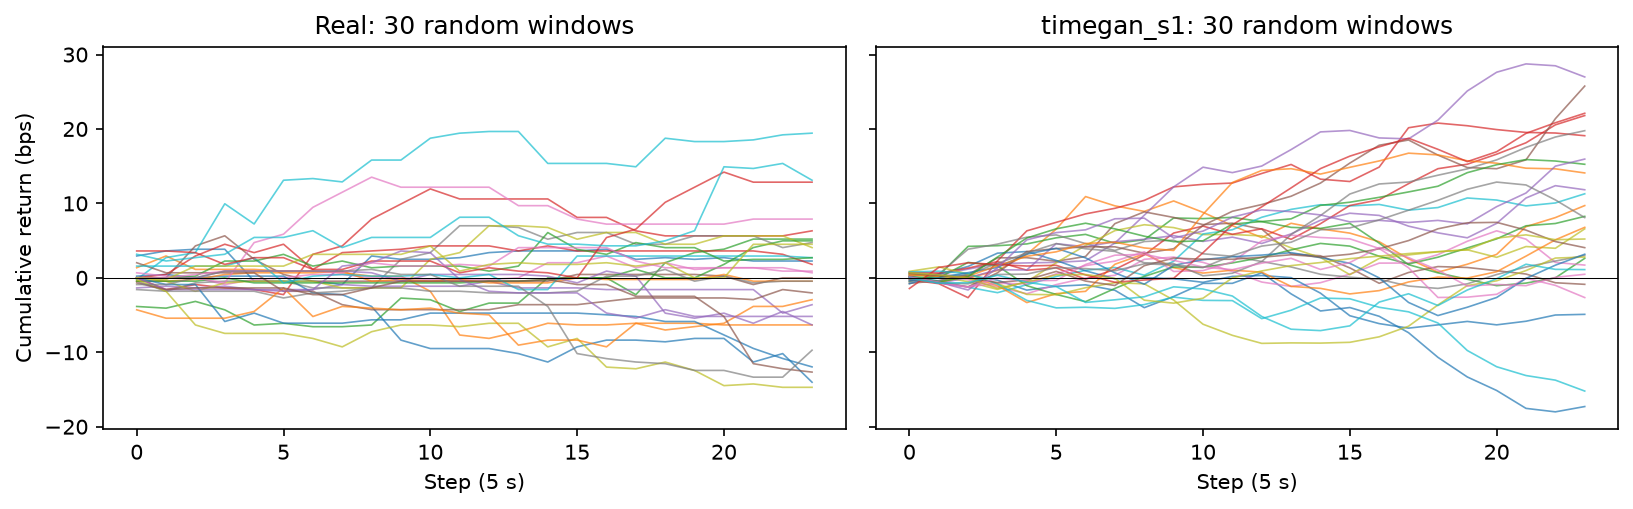

**timegan, seed 2**

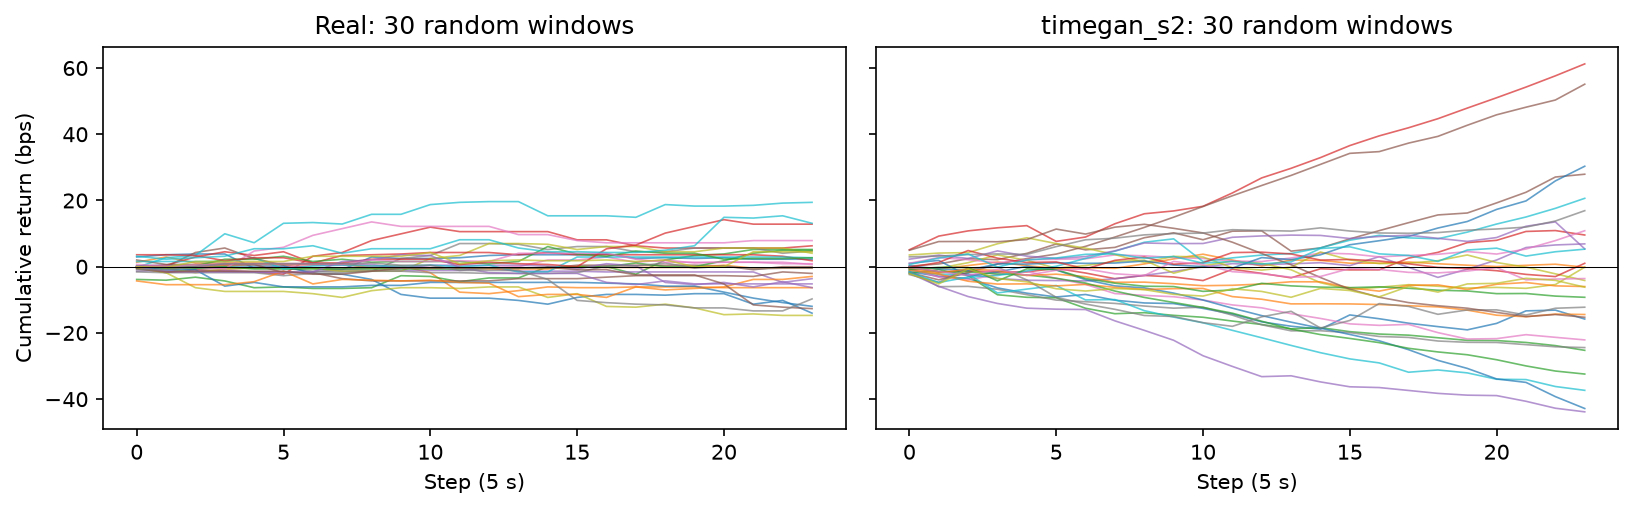

## Distributions

**rnngan, seed 0**

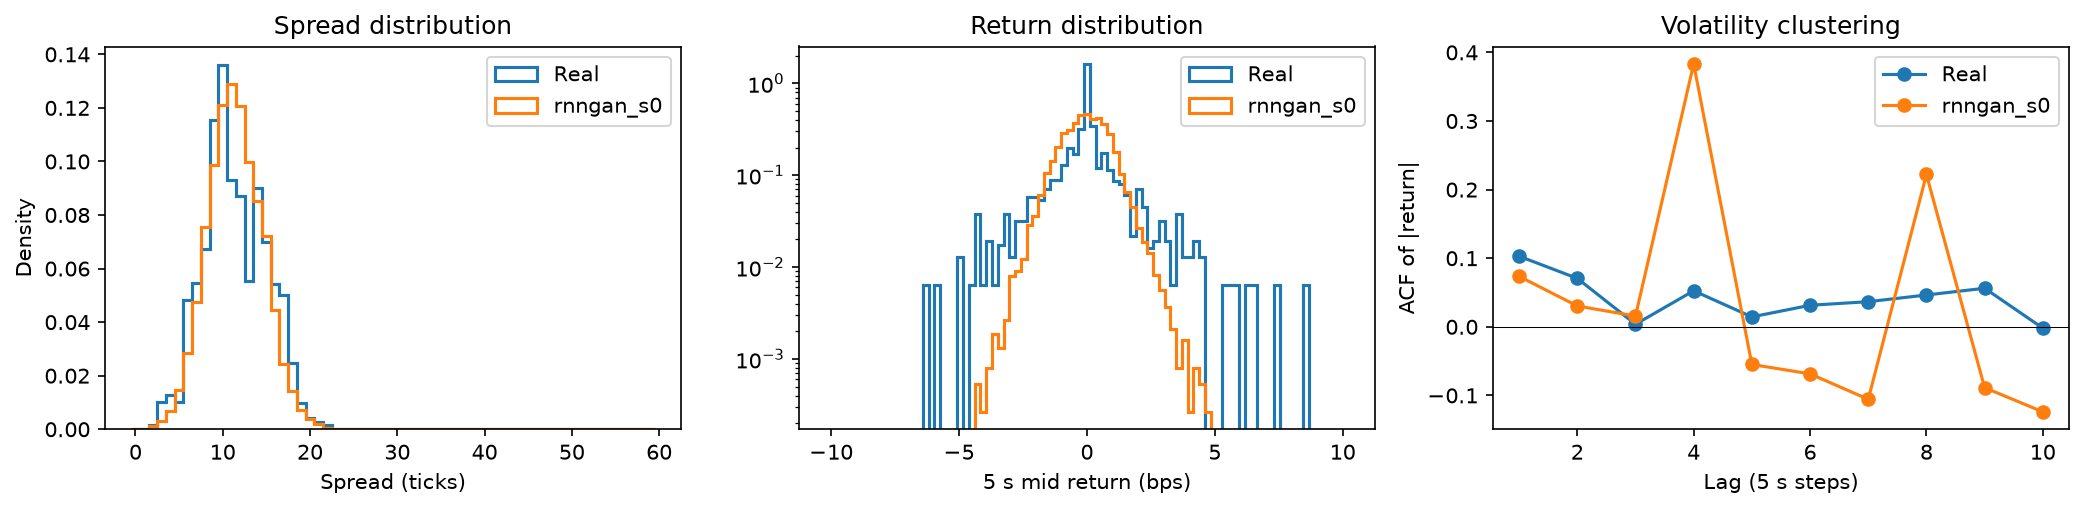

**rnngan, seed 1**

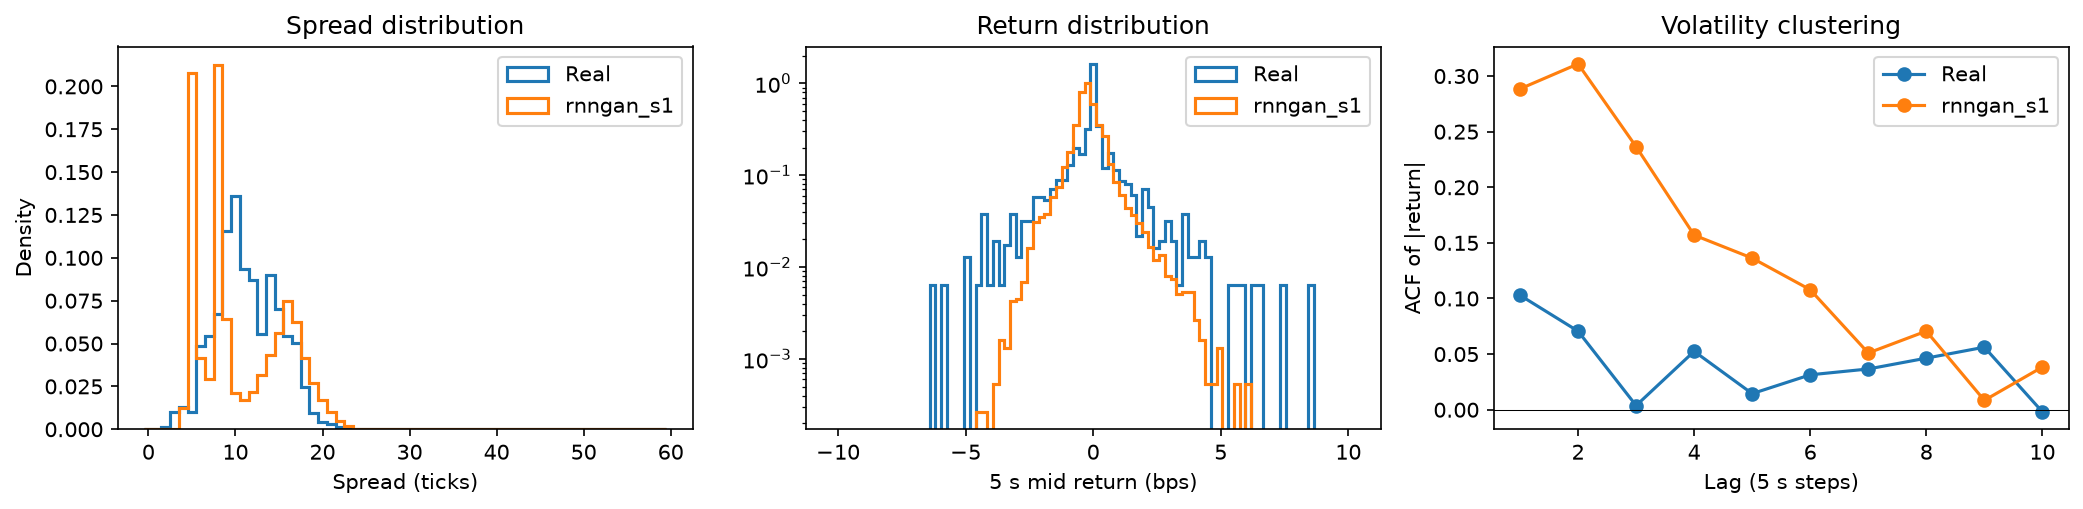

**rnngan, seed 2**

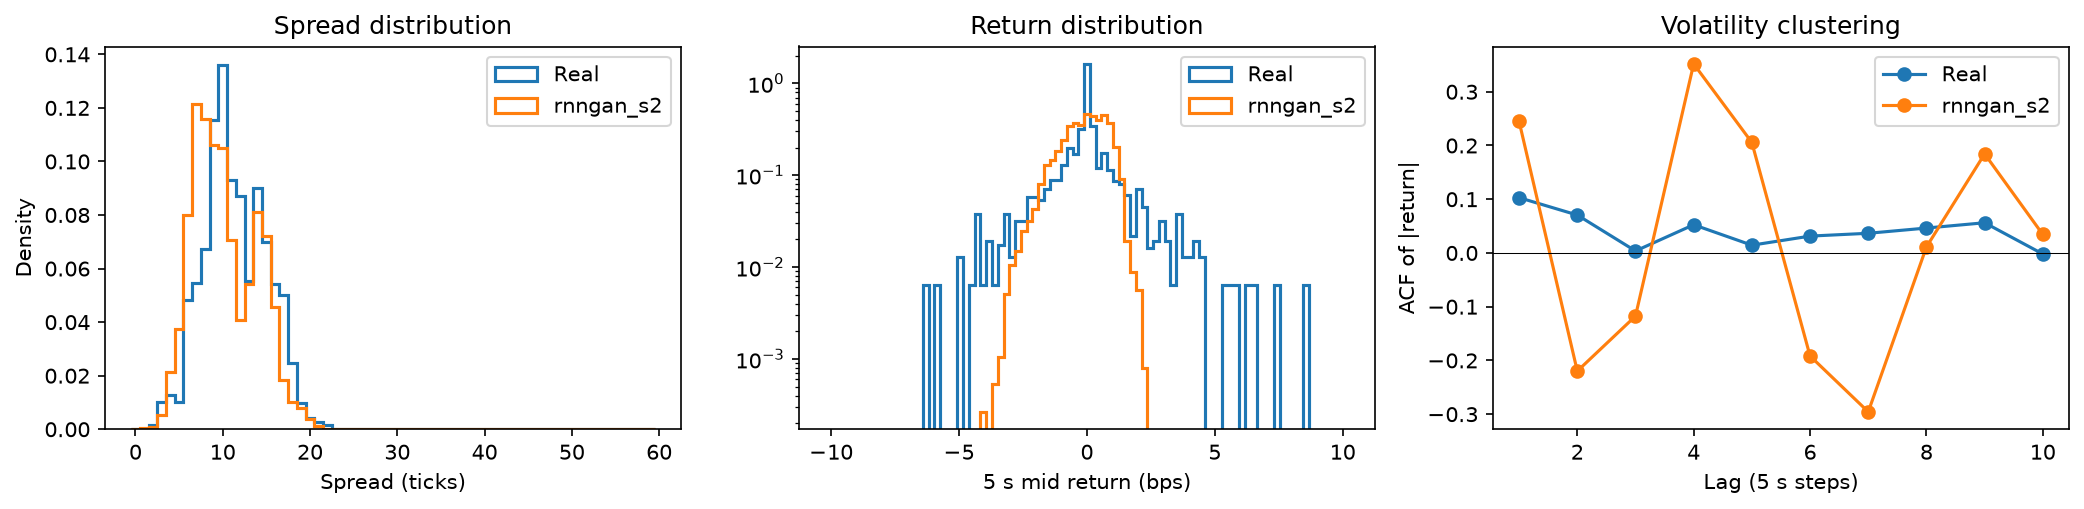

**timegan, seed 0**

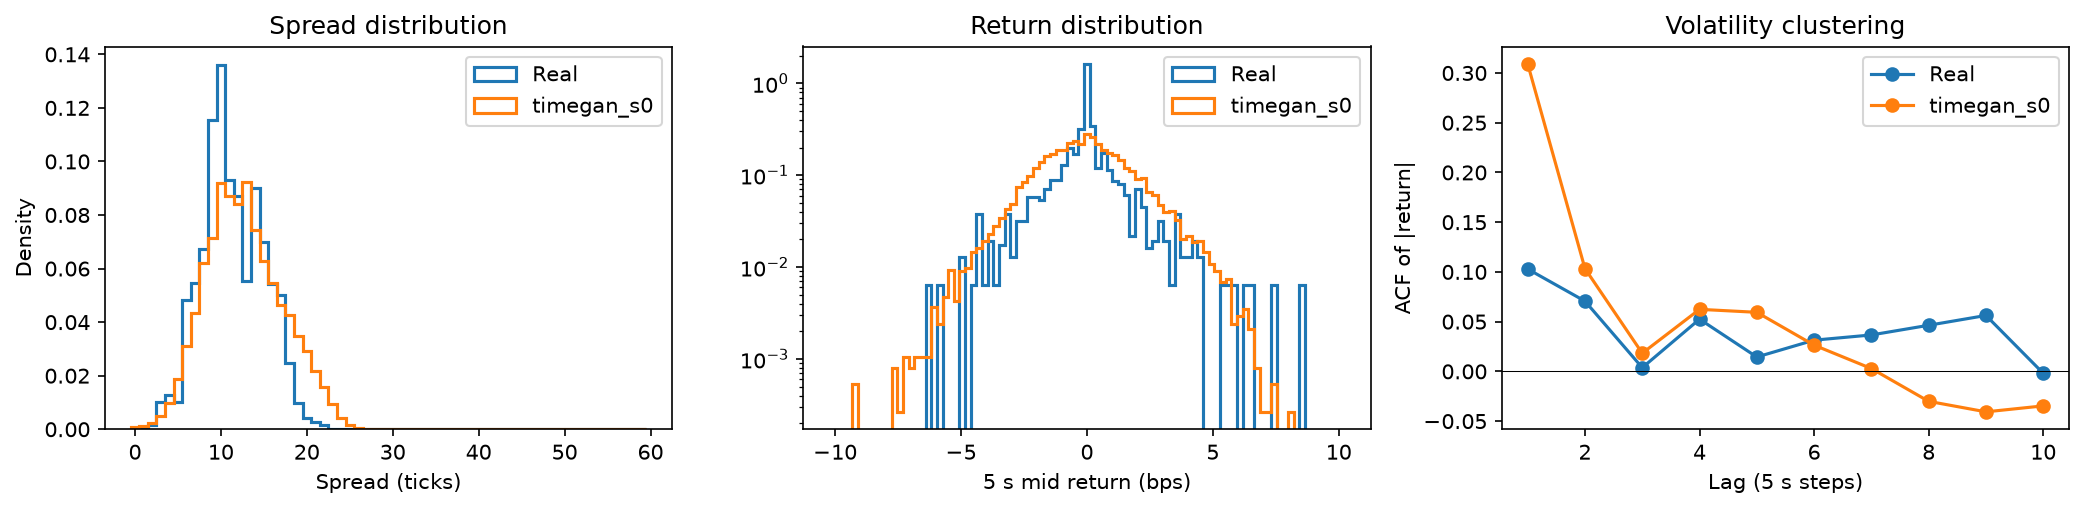

**timegan, seed 1**

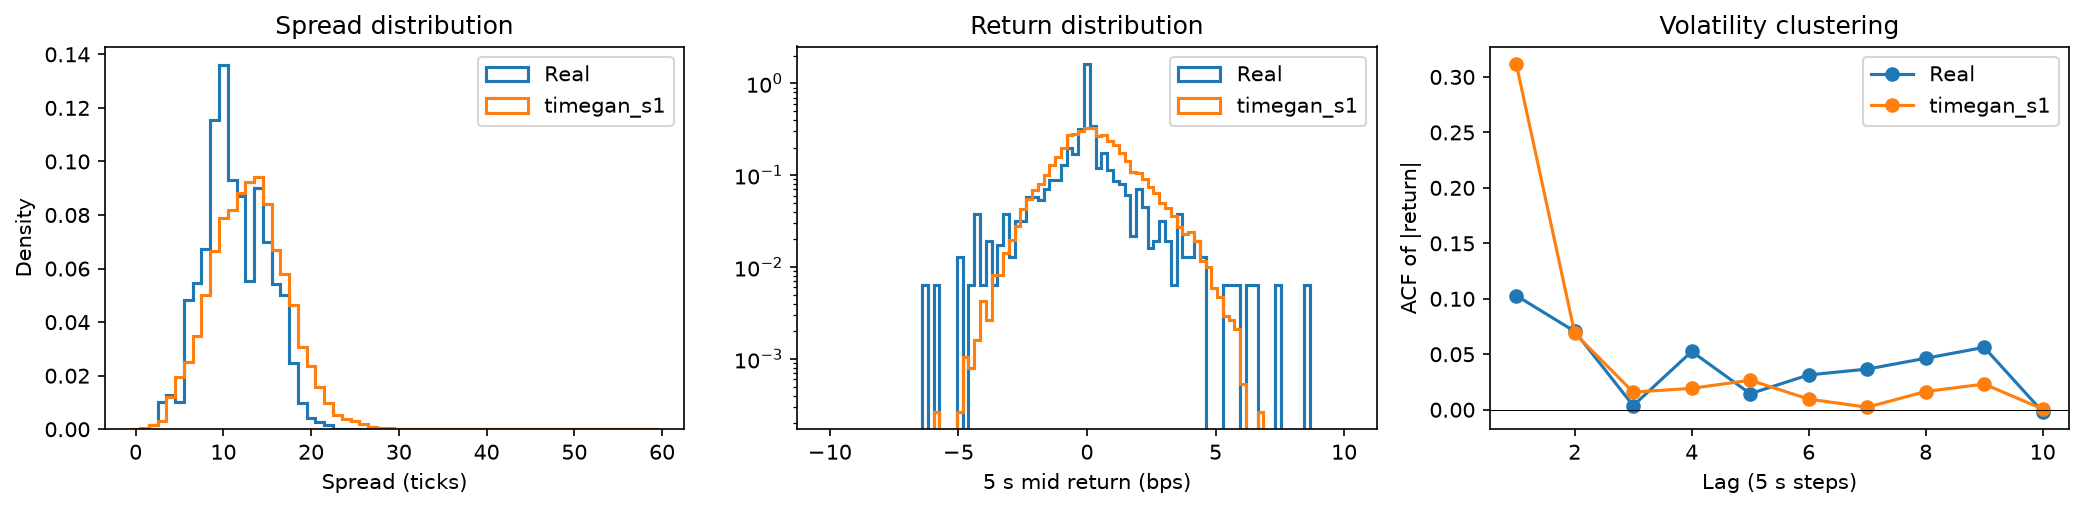

**timegan, seed 2**

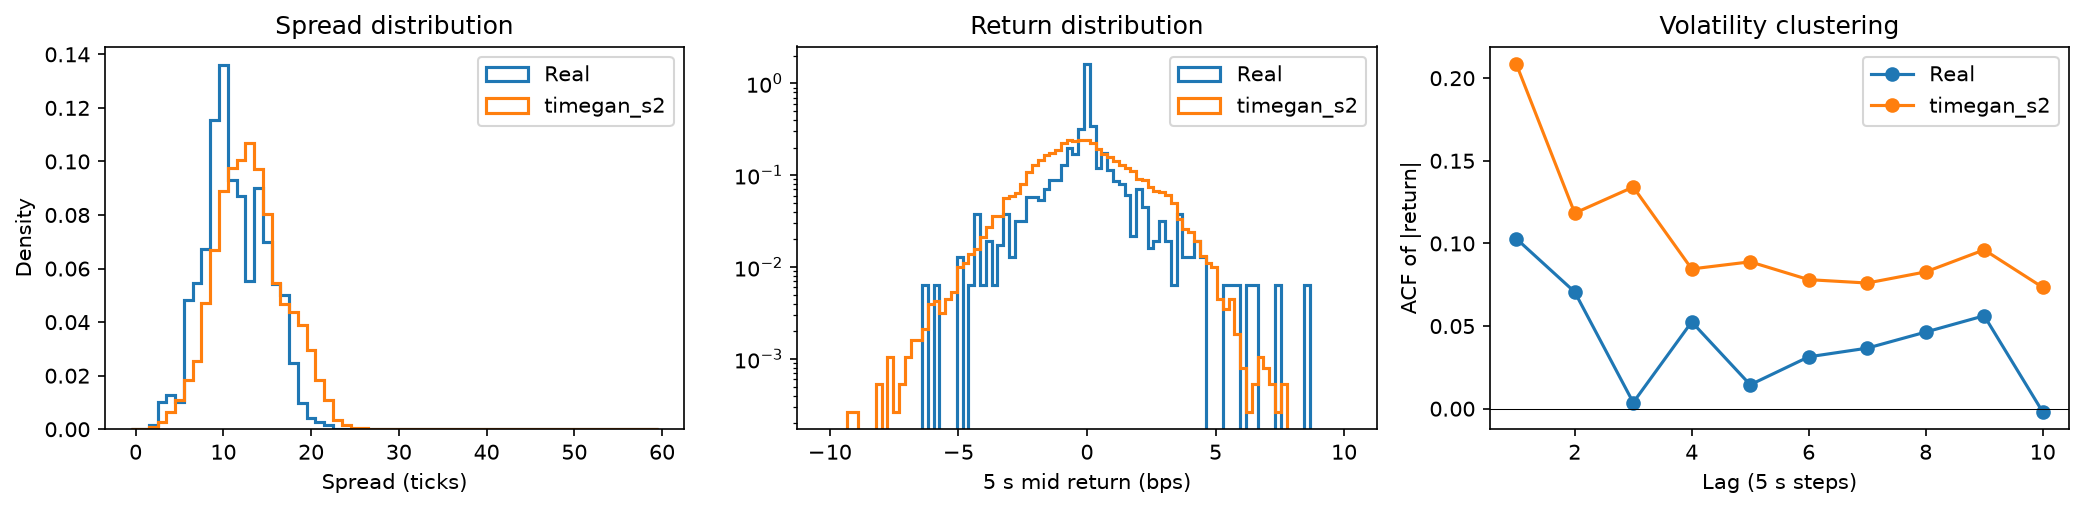

## Ladder + depth

**rnngan, seed 0**

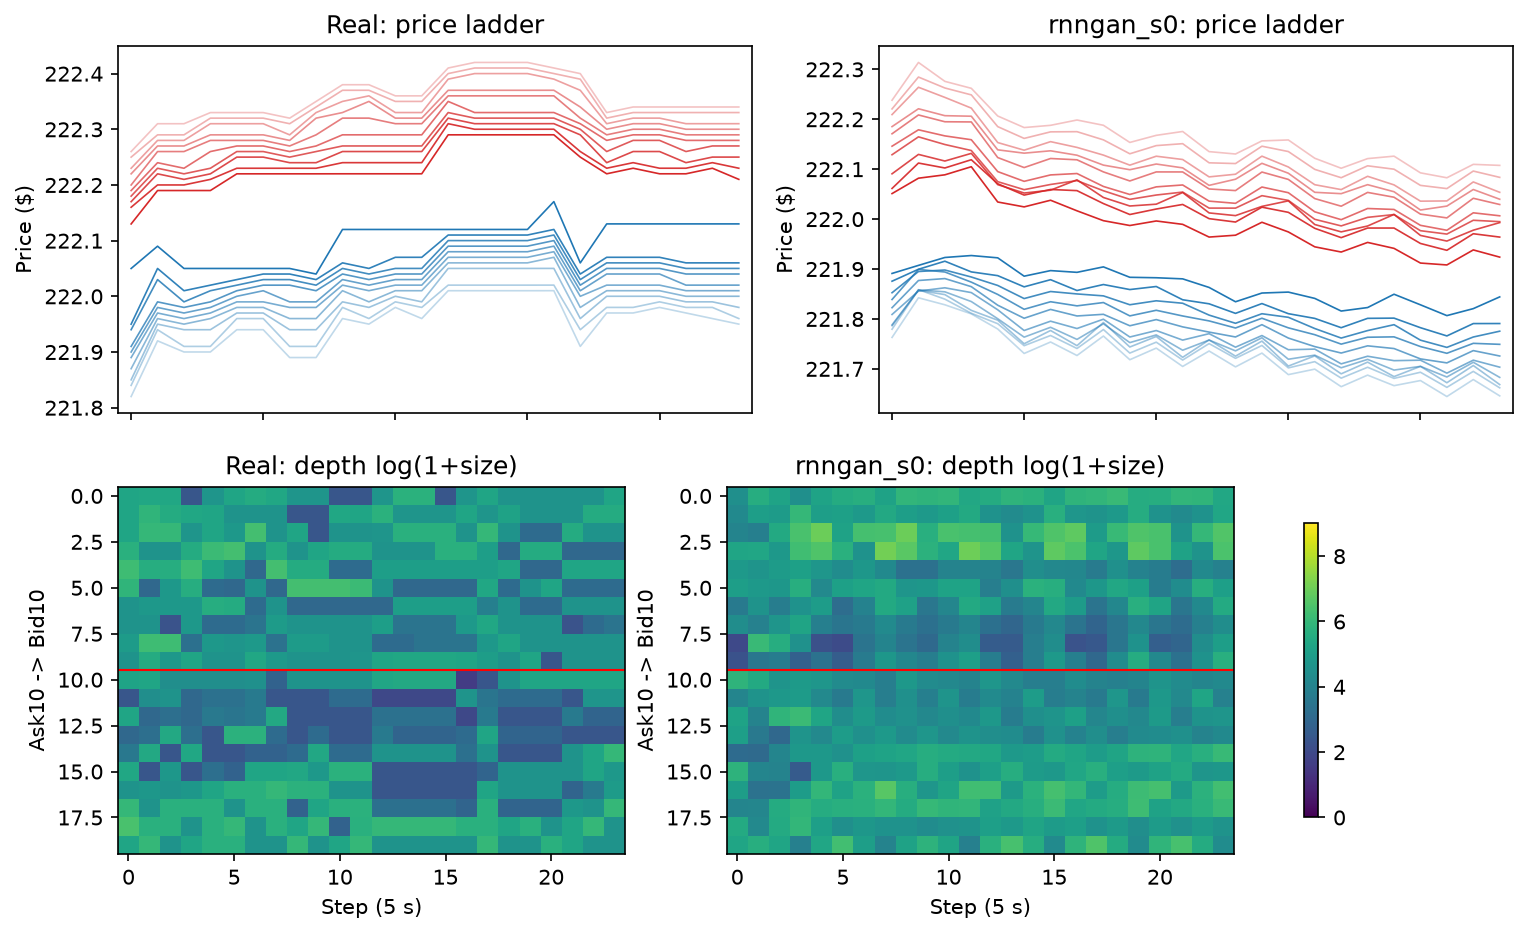

**rnngan, seed 1**

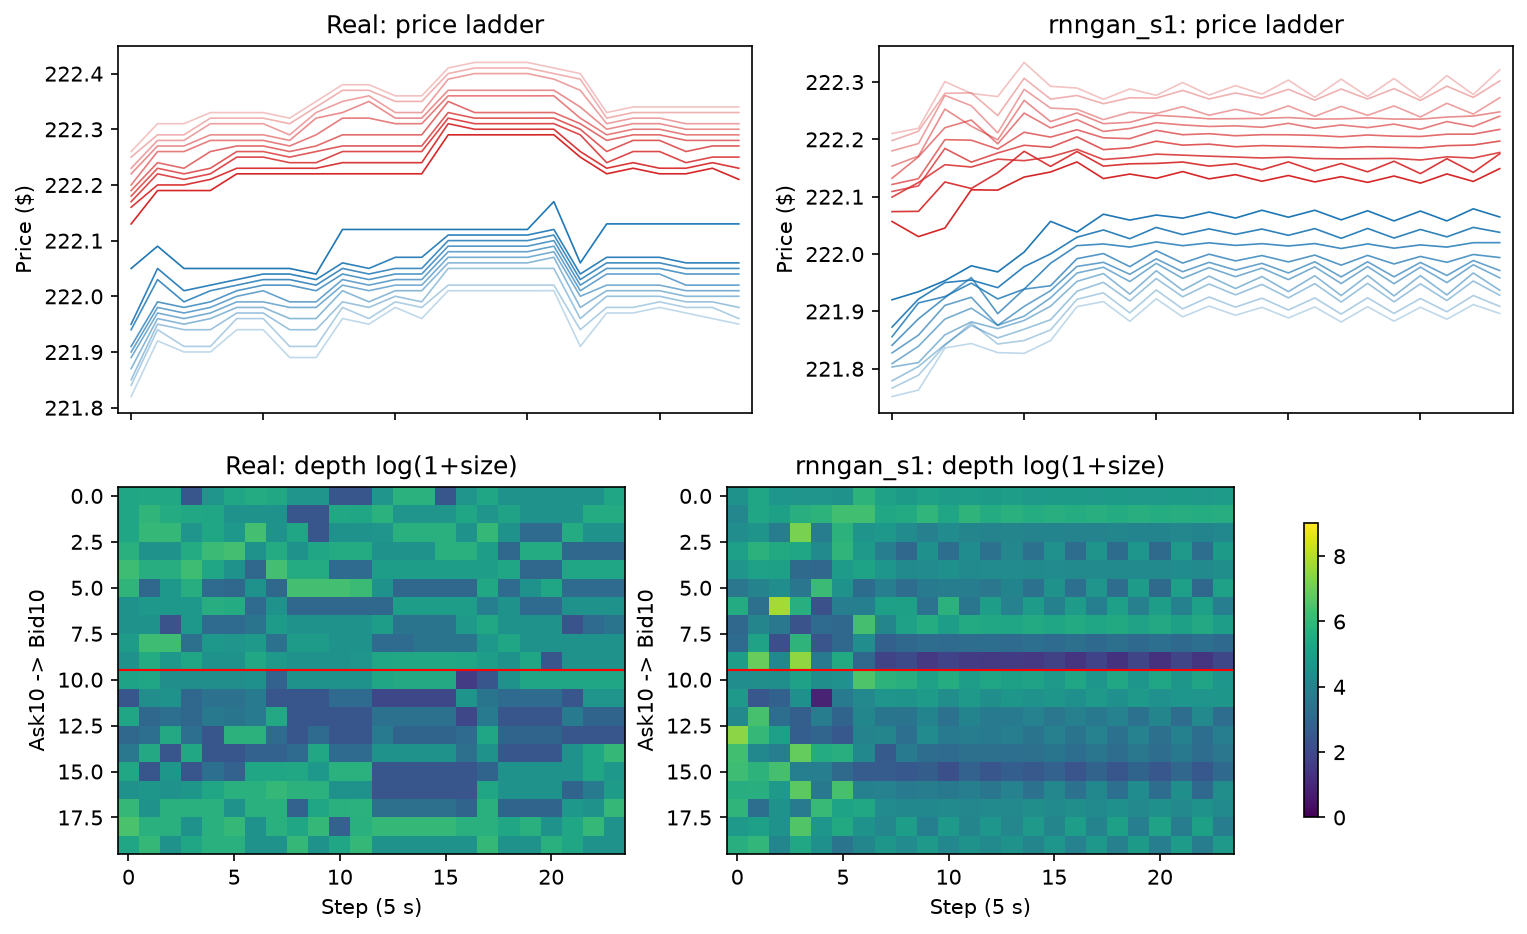

**rnngan, seed 2**

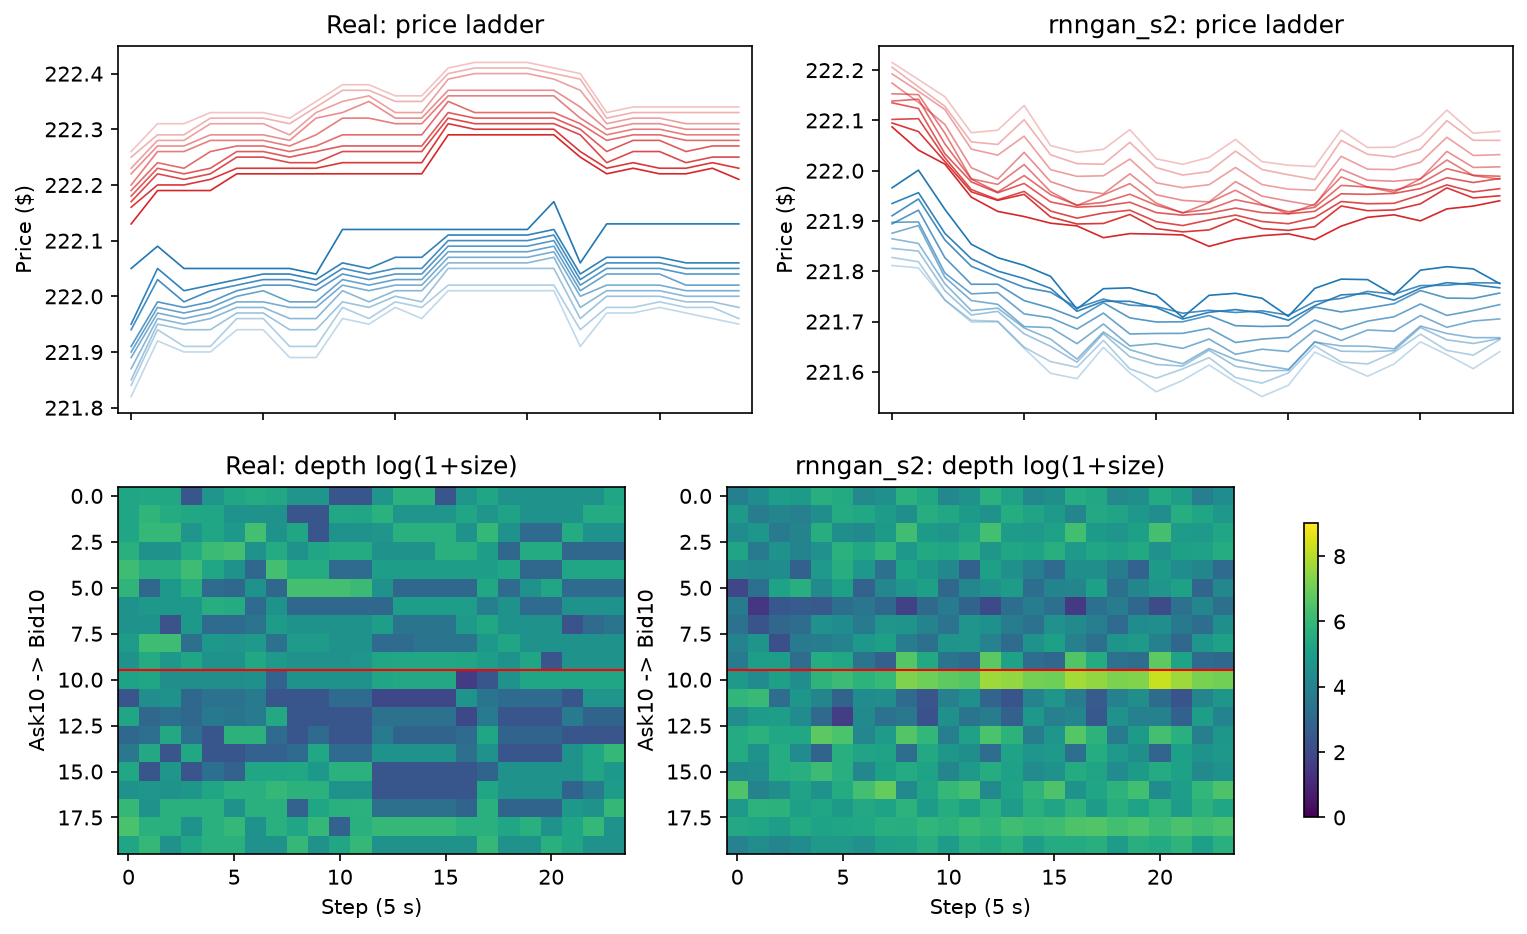

**timegan, seed 0**

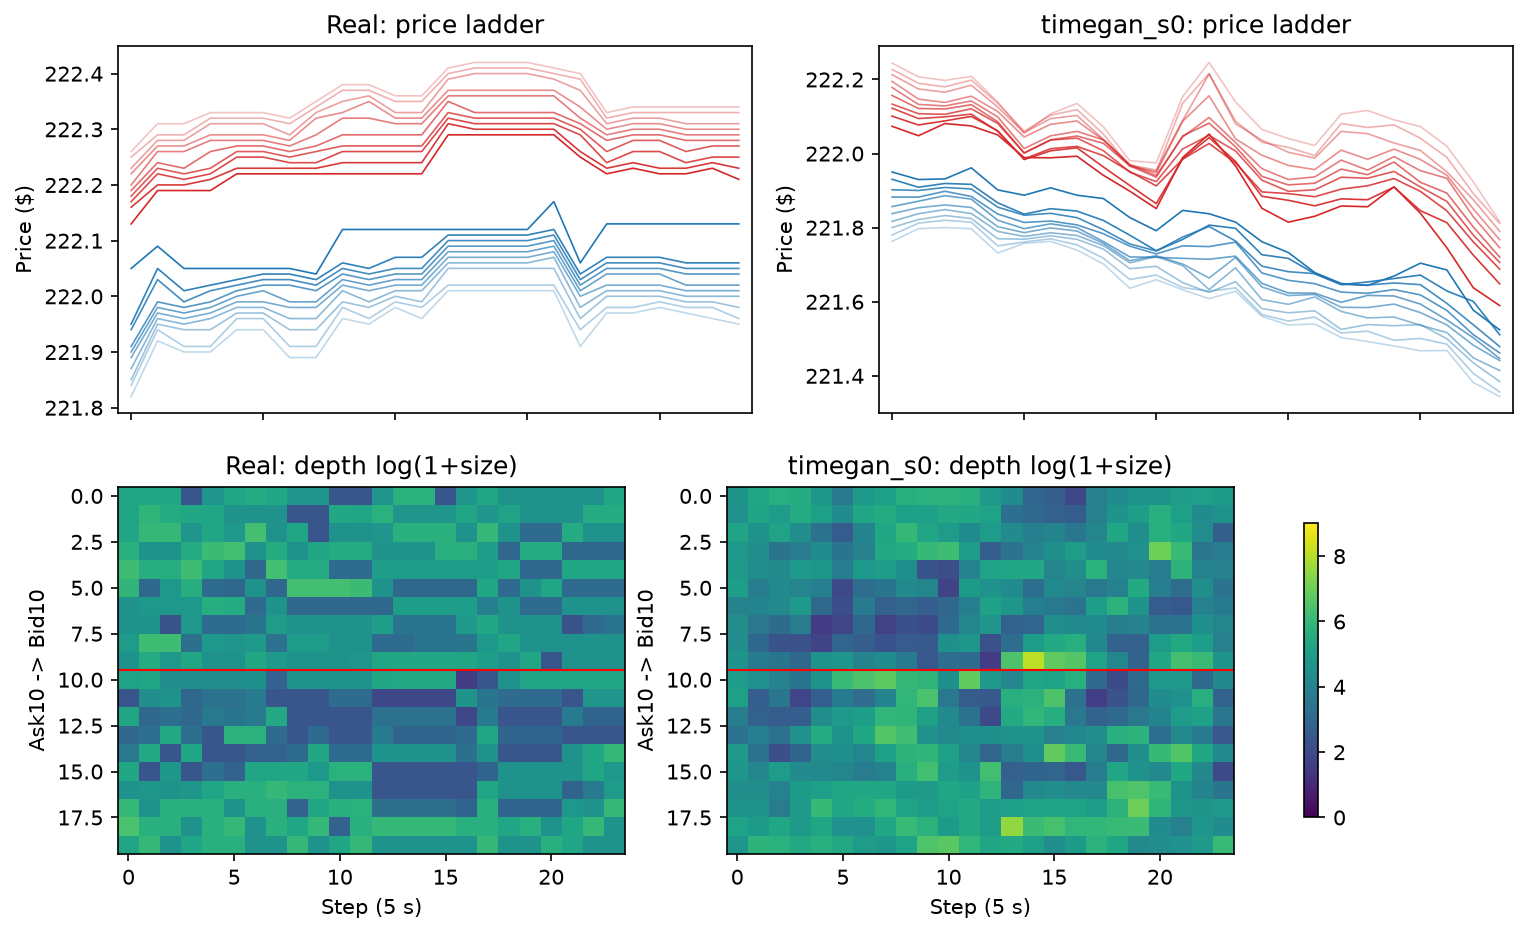

**timegan, seed 1**

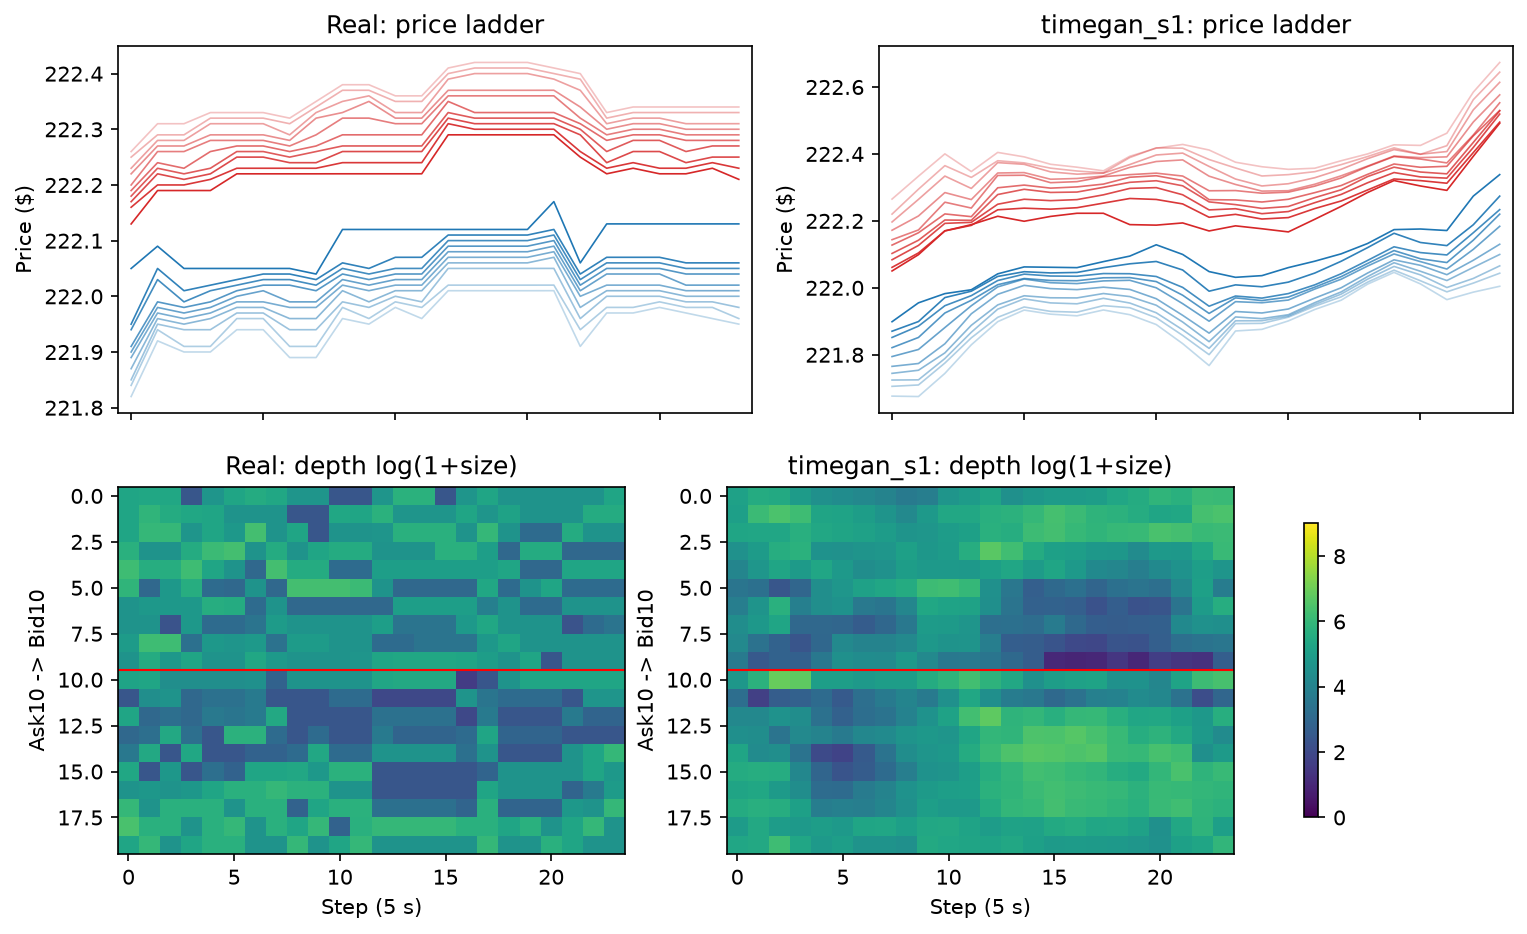

**timegan, seed 2**

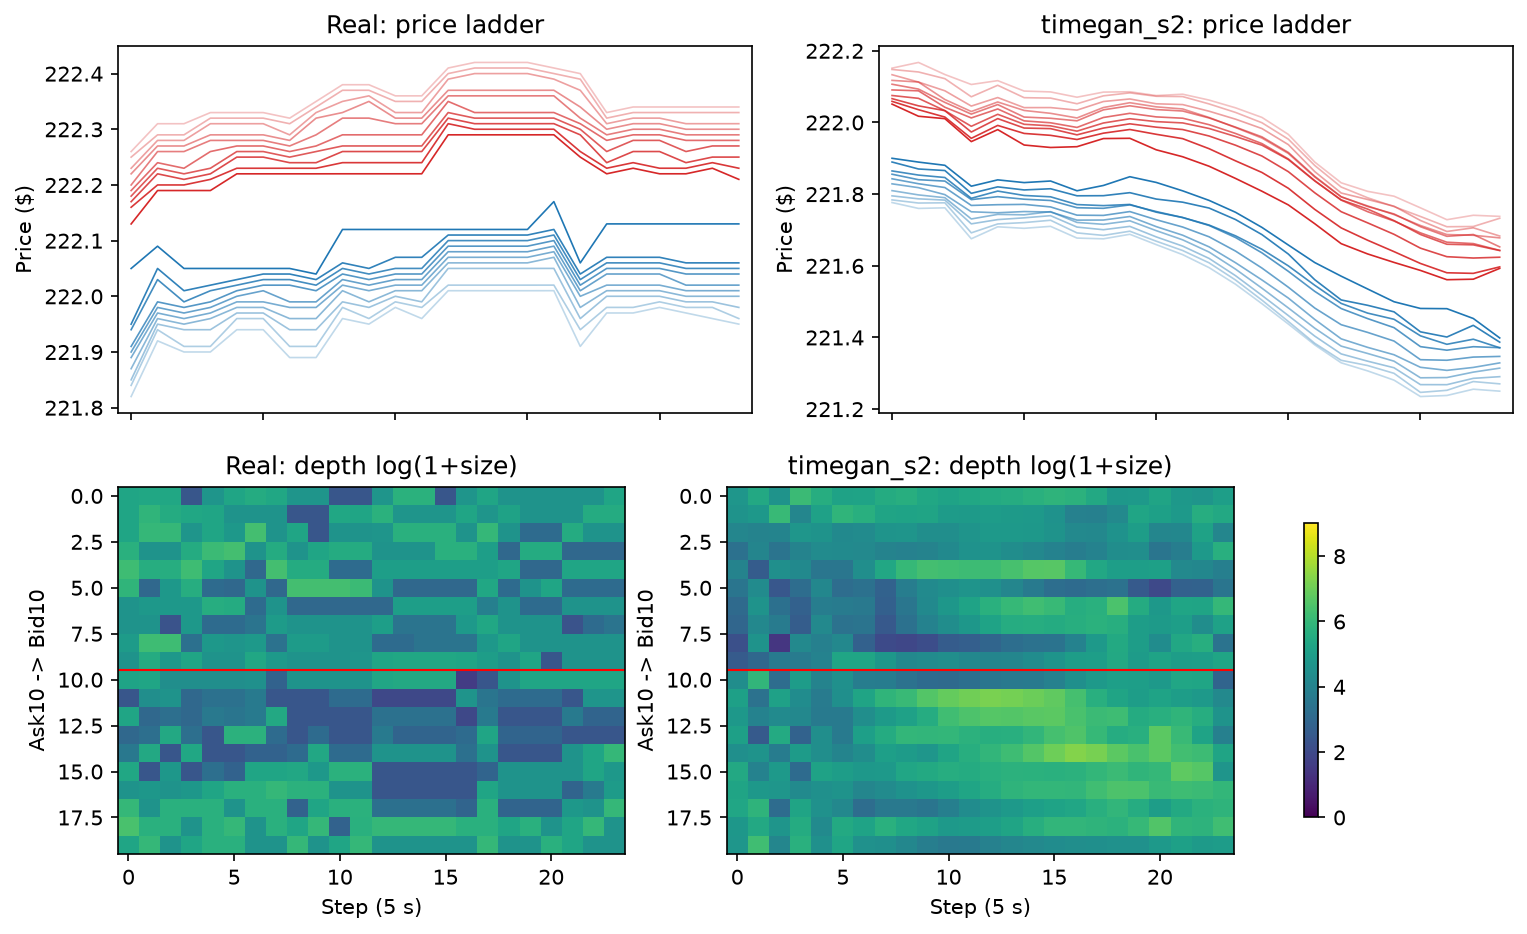

## Training losses

**rnngan, seed 0**

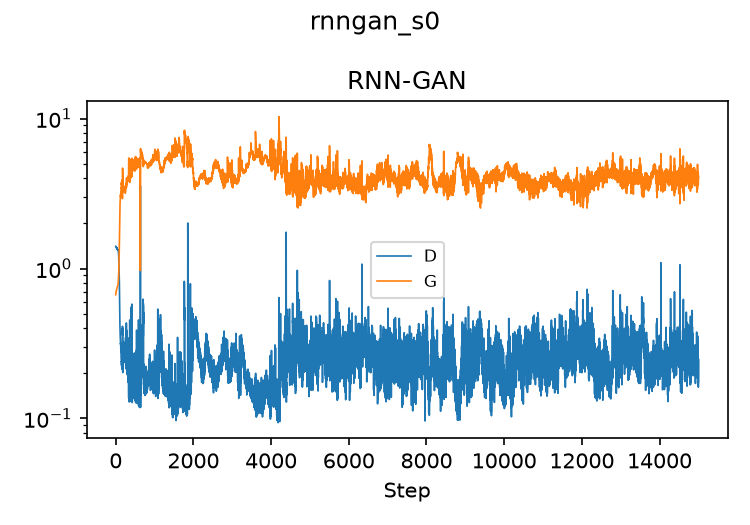

**rnngan, seed 1**

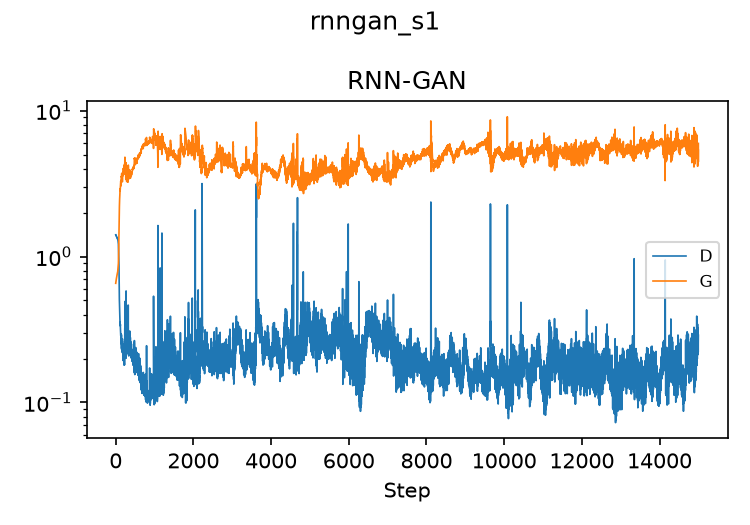

**rnngan, seed 2**

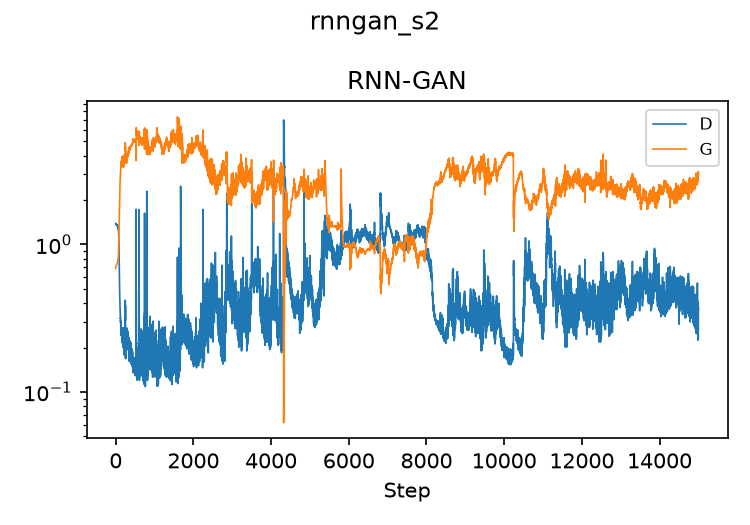

**timegan, seed 0**

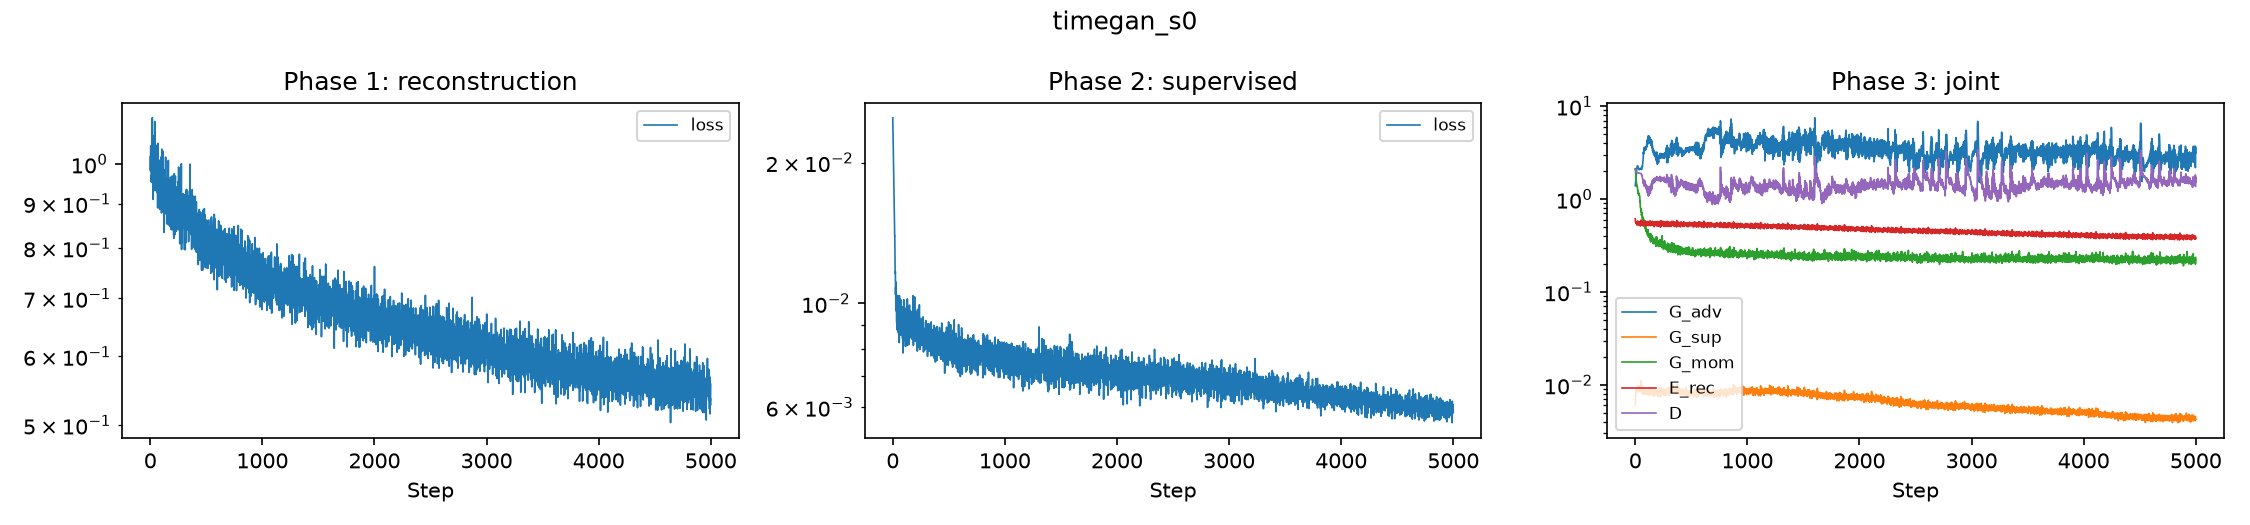

**timegan, seed 1**

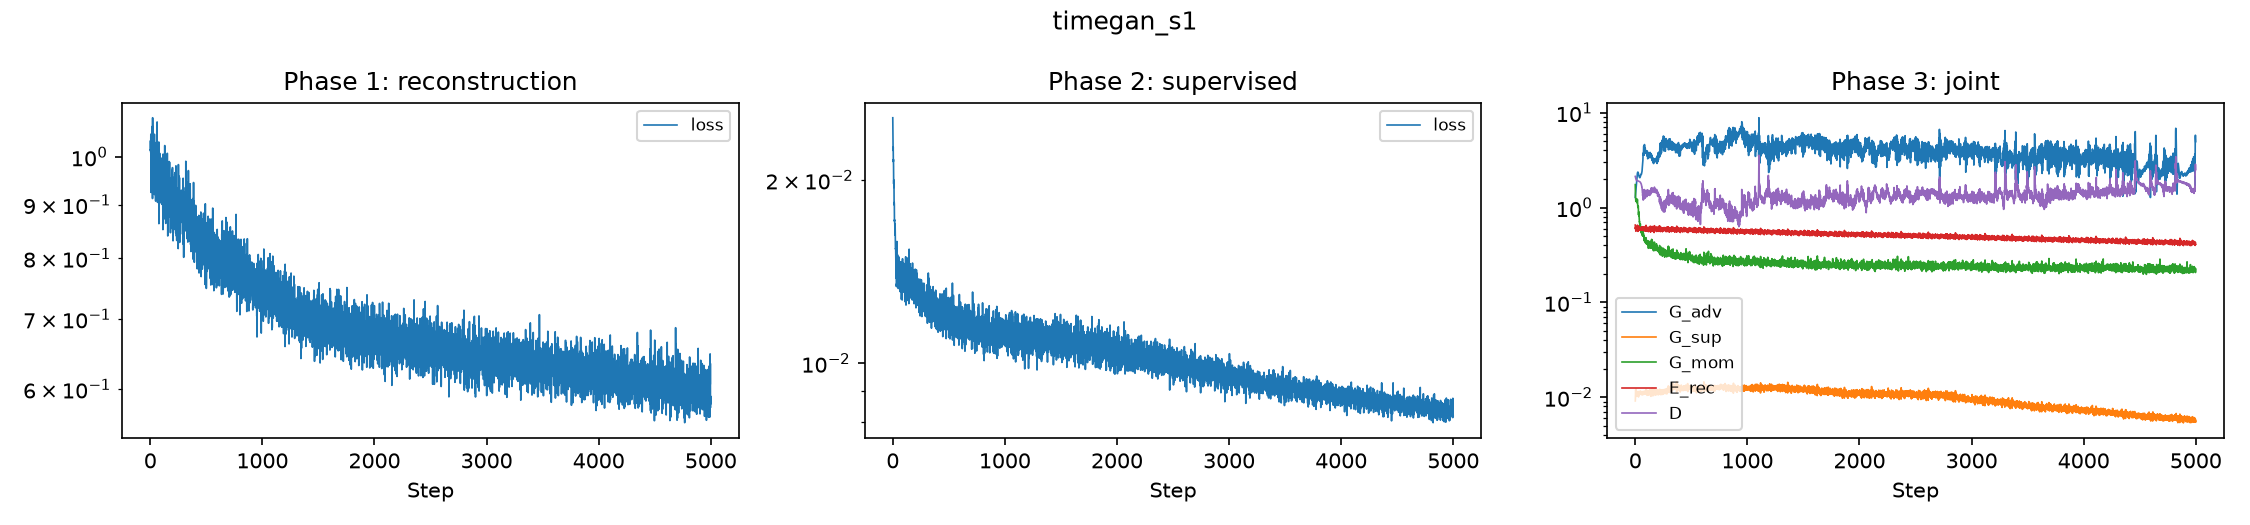

**timegan, seed 2**

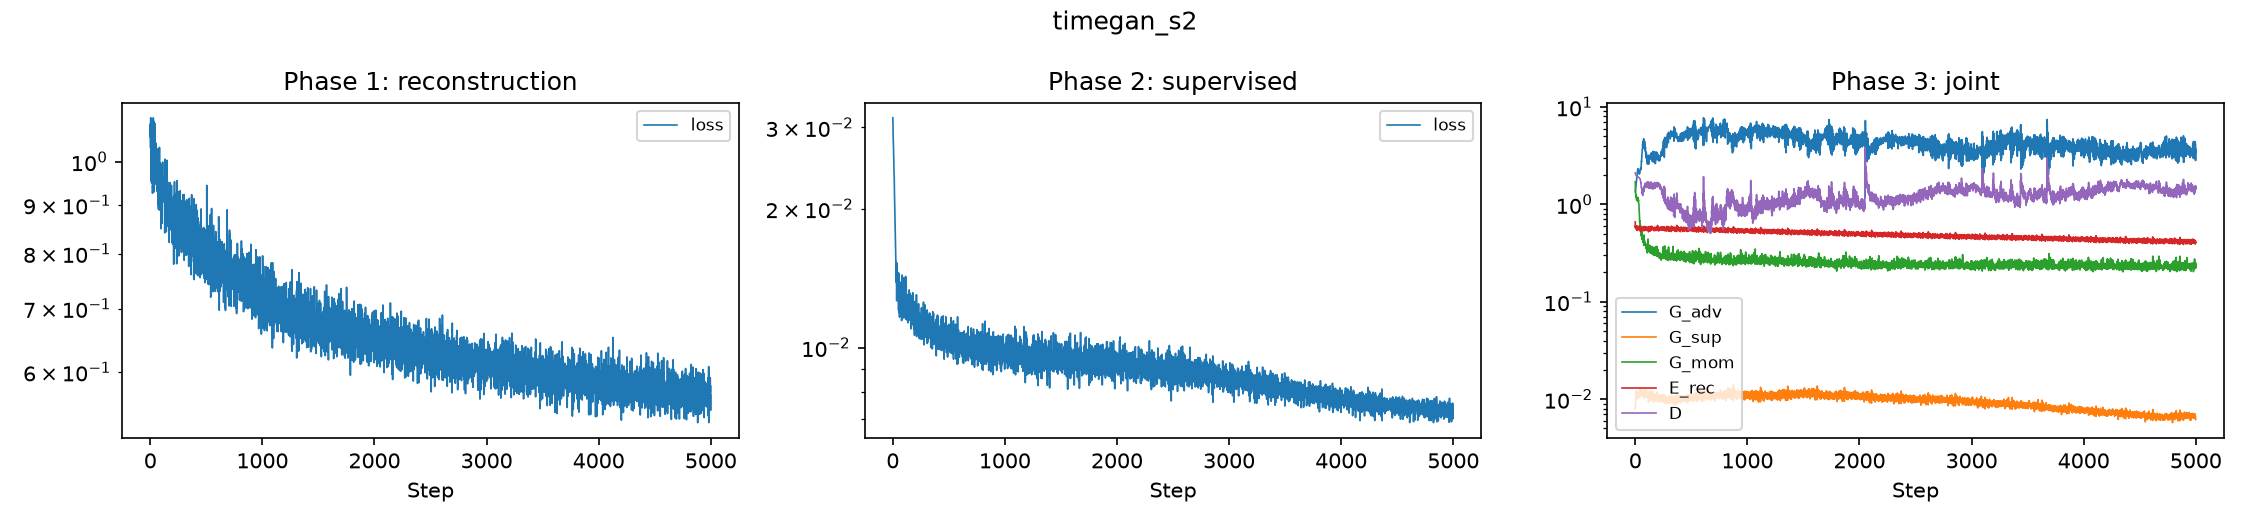

In [6]:
from IPython.display import Image, display, Markdown

kinds = {"val_paths": "Price paths", "val_dists": "Distributions", "val_book": "Ladder + depth", "losses": "Training losses"}
for kind, title in kinds.items():
    display(Markdown(f"## {title}"))
    for model in ["rnngan", "timegan"]:
        for seed in range(3):
            display(Markdown(f"**{model}, seed {seed}**"))
            display(Image(f"figures/{model}_s{seed}_{kind}.png", width=850))

In [9]:
import json, numpy as np, pandas as pd
from IPython.display import display

rows = {"KL spread": ("KL spread vs real", "≤ 0.1"),
        "KL returns": ("KL returns vs real", "≤ 0.1"),
        "Invalid books (%)": ("Any invariant broken (%)", "≤ 1"),
        "Zero returns (%)": ("Zero returns (%)", "≈ 36.6"),
        "Windows trending up (%)": ("Windows trending up (%)", "≈ 50"),
        "Diversity": ("Diversity: std of window-mean spread", "≈ 1.61"),
        "Vol clustering ACF(1)": ("Vol clustering: ACF |ret| lag 1", "≈ 0.10")}
names = {"rnngan": "RNN-GAN", "timegan": "TimeGAN"}
runs = {m: [json.load(open(f"results/{m}_s{s}.json")) for s in range(3)] for m in names}

table = {}
for label, (key, target) in rows.items():
    row = {("", "Target"): target}
    for m, nice in names.items():
        vals = [r["best_val_metrics"][key] for r in runs[m]]
        for s, v in enumerate(vals):
            row[(nice, f"seed {s}")] = f"{v:.3f}"
        row[(nice, "mean ± std")] = f"{np.mean(vals):.3f} ± {np.std(vals):.3f}"
    table[label] = row
for label, field, fmt in [("Best checkpoint step", "best_step", "{:.0f}"), ("Train time (s)", "train_seconds", "{:.0f}")]:
    table[label] = {("", "Target"): ""} | {(names[m], f"seed {s}"): fmt.format(r[field])
                                          for m in names for s, r in enumerate(runs[m])}

df = pd.DataFrame(table).T
df.columns = pd.MultiIndex.from_tuples(df.columns)
df = df.fillna("")
display(df.style
        .set_caption("Validation metrics at each run's best checkpoint (3 seeds per model)")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "center")]},
                           {"selector": "caption", "props": [("font-size", "1.1em"), ("font-weight", "bold")]}]))